<a href="https://colab.research.google.com/github/JISHANA-T/Decision-tree/blob/main/DECISIONTREEE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

In [ ]:
from google.colab import files
uploaded = files.upload()
data = pd.read_excel('GROUP 1.xlsx')

Saving GROUP 1.xlsx to GROUP 1 (1).xlsx


In [ ]:
data = pd.read_excel("GROUP 1.xlsx")

In [ ]:
# Set correct headers
data.columns = data.iloc[0]

# Remove first row
data = data[1:]

# Rename target variable
data.rename(columns={"default payment next month": "default"}, inplace=True)

# Convert all values to numeric
data = data.apply(pd.to_numeric, errors='coerce')

# Drop missing values
data = data.dropna()

In [ ]:
X = data.drop("default", axis=1)
y = data["default"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("AUC:", auc)

Accuracy: 0.7807308970099668
Confusion Matrix:
 [[215  14]
 [ 52  20]]
AUC: 0.7114264919941776


In [ ]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance.head(10))

      Feature  Importance
6       PAY_0    0.432595
1   LIMIT_BAL    0.137134
9       PAY_4    0.097902
15  BILL_AMT4    0.063571
12  BILL_AMT1    0.055641
16  BILL_AMT5    0.049327
11      PAY_6    0.047749
10      PAY_5    0.038917
5         AGE    0.028671
17  BILL_AMT6    0.026637


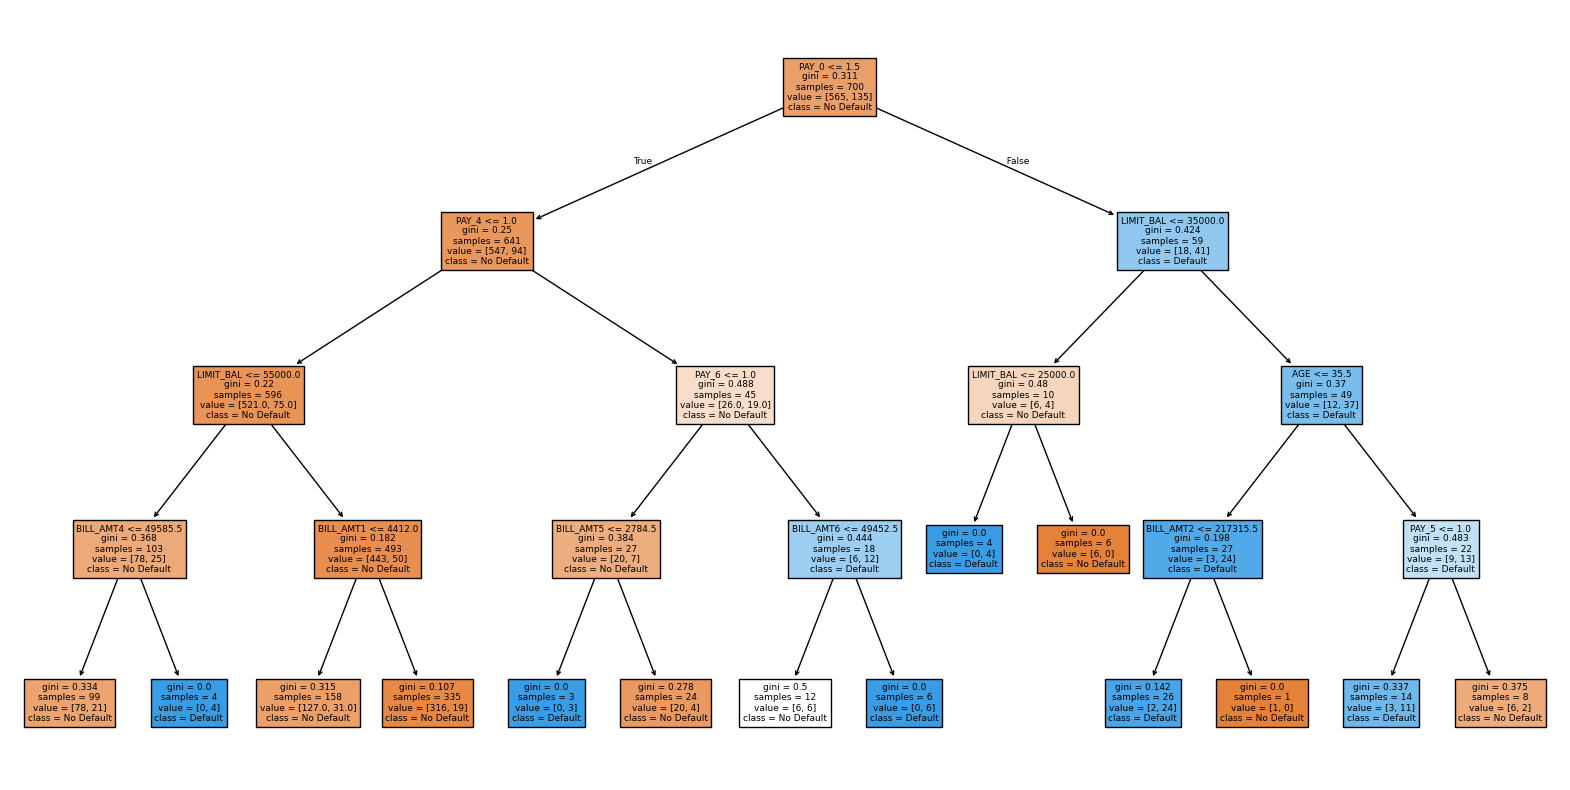

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X.columns, class_names=["No Default","Default"], filled=True)
plt.show()

**Interpretation**

The Decision Tree Classifier was applied to predict customer default using financial and behavioral variables. The model achieved an accuracy of approximately 78.07%, indicating that it correctly classified around 78 out of 100 customers. This suggests that the model has a reasonably good predictive capability and can serve as a useful tool for initial credit risk assessment. However, accuracy alone does not fully capture the model’s effectiveness.

**Confusion Matrix Analysis**

The confusion matrix shows exactly where the model succeeded and where it failed:


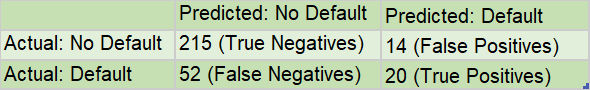

The confusion matrix shows that the model correctly identified most non-defaulters (215) and some defaulters (20), but it misclassified 14 good customers as risky and failed to detect 52 actual defaulters. The high number of false negatives is a major concern, as it means risky borrowers are being treated as safe, potentially leading to financial losses for the institution.

**The Area Under the ROC Curve (AUC)** of 0.71 indicates that the model has a "fair" ability to distinguish between those who will default and those who won't (where 0.5 is random guessing and 1.0 is perfect).

**Key Predictors**

The model found that these three factors were the most influential in making a prediction:
       PAY_0 - 43.26%
       LIMIT_BAL - 13.71%
       PAY_4 - 9.79%

**Structural Analysis of the Decision Tree**

The decision tree shows a step-by-step classification process starting from the root node, where PAY_0 (recent repayment status) is the most important factor in predicting default. Customers with delayed payments are further evaluated using other repayment variables (like PAY_2 and PAY_6), indicating that repeated delays increase default risk. For customers with good repayment behavior, credit limit (LIMIT_BAL) helps determine the final outcome, with higher limits generally associated with non-default. The leaf nodes represent the final classification, and the Gini impurity indicates how pure each decision group is, with lower values showing more accurate classification.

Overall, the model is easy to understand and explain, which is helpful for decision-making and regulatory needs. However, it misses many actual defaulters and has only moderate accuracy, so it may not be reliable on its own. Using more advanced models like Random Forest addressing class imbalance can help improve its performance.